In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd "/content/drive/MyDrive/VSM Neural Lyapunov"

/content/drive/MyDrive/VSM Neural Lyapunov


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import timeit

# 自动选择 GPU 或 CPU
device = torch.device("cuda")
print(f"Using device: {device}")

# 设置随机种子以保证结果可复现
torch.manual_seed(42)
np.random.seed(42)

# ---------- System Parameters ----------
Pm = 2.0
M  = 1.0
D  = 0.1
K  = 2.5
delta_s = np.arcsin(Pm / K)

print(f"Original equilibrium delta_s: {delta_s:.4f} rad")
print("System successfully shifted to the origin [0, 0].")

# ---------- System Dynamics ----------
def f_value(x):
    """
    Computes the system dynamics.
    x: [batch_size, 2] tensor
    Returns: [batch_size, 2] tensor
    """
    x1 = x[:, 0:1]
    x2 = x[:, 1:2]

    dx1 = x2
    dx2 = (Pm - K * torch.sin(x1 + delta_s) - D * x2) / M
    return torch.cat([dx1, dx2], dim=1)

# ---------- Helper Functions (Following your pattern) ----------
def linearize_dynamics(f_func, x0_tensor):
    """
    Computes the Jacobian of the dynamics f at x0 to get the linearized matrix A.
    """
    # Use torch's functional jacobian to get the A matrix (df/dx at x0)
    A = torch.autograd.functional.jacobian(f_func, x0_tensor)
    # Squeeze to remove batch dimensions of size 1
    A = A.squeeze()
    return A

def get_Lf(A_matrix):
    """
    Estimates the Lipschitz constant L_f for the dynamics using the linearized system.
    """
    # The operator 2-norm is the largest singular value.
    L_f = torch.linalg.norm(A_matrix, ord=2)
    return L_f.item()

Using device: cuda
Original equilibrium delta_s: 0.9273 rad
System successfully shifted to the origin [0, 0].


Shifted Stable Equilibrium Point (SEP): [0.0, 0.0]
Shifted Unstable Equilibrium Point (UEP): [1.2870, 0.0]


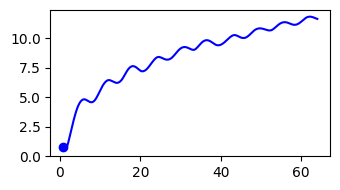

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ---------- 1. 系统参数 ----------
Pm = 2.0
M  = 1.0
D  = 0.1
K  = 2.5
delta_s = np.arcsin(Pm / K)

# 计算不稳定平衡点 (UEP) 在平移坐标系下的位置
# 原始 UEP = pi - delta_s. 平移后的 UEP_x1 = (pi - delta_s) - delta_s = pi - 2*delta_s
x1_uep = np.pi - 2 * delta_s
print(f"Shifted Stable Equilibrium Point (SEP): [0.0, 0.0]")
print(f"Shifted Unstable Equilibrium Point (UEP): [{x1_uep:.4f}, 0.0]")

# ---------- 2. 纯 Numpy 版本的动力学 (用于 scipy 积分) ----------
def system_dynamics(t, x):
    x1, x2 = x
    dx1 = x2
    dx2 = (Pm - K * np.sin(x1 + delta_s) - D * x2) / M
    return [dx1, dx2]

# ---------- 3. 仿真设置 ----------
t_span = (0, 10) # 仿真 30 秒
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# 设置几组极具代表性的初始条件 [x1(0), x2(0)]
initial_conditions = [
    [0.8,0.8]
]

# ---------- 4. 绘图 ----------
fig, (ax1) = plt.subplots(1, 1, figsize=(3.5, 2))

colors = ['blue', 'green', 'orange', 'red', 'purple']

for ic, color in zip(initial_conditions, colors):
    sol = solve_ivp(system_dynamics, t_span, ic, t_eval=t_eval)

    # 画相图 (Phase Portrait)
    ax1.plot(sol.y[0], sol.y[1], color=color, label=f'$x_0$=[{ic[0]}, {ic[1]}]')
    ax1.plot(ic[0], ic[1], 'o', color=color) # 标记起点

    # 画时域曲线 x1(t)
    # ax2.plot(sol.t, sol.y[0], color=color, label=f'$x_0$=[{ic[0]}, {ic[1]}]')

# 相图装饰
# ax1.plot(0, 0, 'r*', markersize=12, label='SEP (Origin)')
# ax1.plot(x1_uep, 0, 'kX', markersize=10, label='UEP')
# ax1.axvline(0, color='k', linestyle='--', alpha=0.3)
# ax1.axhline(0, color='k', linestyle='--', alpha=0.3)
# ax1.set_xlabel('$x_1$')
# ax1.set_ylabel('$x_2$')
# ax1.set_title('Phase Portrait (State Space)')
# ax1.legend()
# ax1.grid(True)

# # 时域图装饰
# ax2.axhline(0, color='k', linestyle='--', alpha=0.5, label='SEP')
# ax2.axhline(x1_uep, color='k', linestyle=':', alpha=0.5, label='UEP')
# ax2.set_xlabel('Time (s)')
# ax2.set_ylabel('$x_1(t)$ (Shifted Angle)')
# ax2.set_title('Time Domain Trajectory of Angle')
# ax2.legend()
# ax2.grid(True)

plt.tight_layout()
plt.savefig('unstable', dpi=300)
plt.show()

In [ ]:
# ---------- Block 2: 还原纯 Tanh 架构 ----------
N_SAMPLES = 20000
D_IN = 2
H1 = 16
D_PHI_OUT = 2
LEARNING_RATE = 0.005
EPOCHS = 20000

DELTA = 1e-3

# 保持一个适中的验证半径，确保它在真实物理 ROA 内部
VERIFICATION_RADIUS = 0.5
GRID_DENSITY = 4000
TAU = 2 * VERIFICATION_RADIUS * np.sqrt(D_IN) / GRID_DENSITY

class LyapunovNetwork(nn.Module):
    def __init__(self, d_in, h1, d_out):
        super(LyapunovNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, h1),
            nn.Tanh(),
            nn.Linear(h1, h1),
            nn.Tanh(),
            nn.Linear(h1, d_out)
        )

    def forward(self, x):
        phi = self.net(x)
        # 移除 0.1 * x**2，还原你的原始架构！
        # 让 Tanh 的饱和特性在边角自然压制梯度
        V = torch.sum(phi**2, dim=1, keepdim=True)
        return V

model = LyapunovNetwork(D_IN, H1, D_PHI_OUT).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

x = torch.randn(N_SAMPLES, D_IN)
x = x / torch.norm(x, dim=1, keepdim=True) * (VERIFICATION_RADIUS * torch.rand(N_SAMPLES, 1))
x = x.to(device)
x_0 = torch.zeros([1, D_IN]).to(device)

A_matrix = linearize_dynamics(f_value, x_0)
L_f = get_Lf(A_matrix)
print(f"Linearized Matrix A:\n{A_matrix.cpu().numpy()}")
print(f"Estimated Lipschitz constant for dynamics, L_f: {L_f:.4f}")

Linearized Matrix A:
[[ 0.   1. ]
 [-1.5 -0.1]]
Estimated Lipschitz constant for dynamics, L_f: 1.5060


In [ ]:
# ---------- Block 3: Training Loop with Verification (Corrected) ----------
start_time = timeit.default_timer()
loss_history = []
verification_history = []

for epoch in range(EPOCHS + 1):
    model.train()

    x.requires_grad_(True)
    f_tensor = f_value(x)
    V_candidate = model(x)
    V_at_origin = model(x_0)

    grad_V = torch.autograd.grad(
        V_candidate,
        x,
        grad_outputs=torch.ones_like(V_candidate),
        create_graph=True
    )[0]

    lie_derivative = torch.sum(grad_V * f_tensor, dim=1, keepdim=True)

    # 我们希望 lie_derivative 严格小于 -DELTA
    loss = V_at_origin + 2 * F.relu(lie_derivative + DELTA).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    x = x.detach()
    loss_history.append(loss.item())

    if epoch % 500 == 0:
        model.eval()
        with torch.no_grad():
            axis = np.linspace(-VERIFICATION_RADIUS, VERIFICATION_RADIUS, GRID_DENSITY)
            grid = np.meshgrid(axis, axis)
            grid_points = np.stack([g.ravel() for g in grid], axis=1)
            grid_points = grid_points[np.linalg.norm(grid_points, axis=1) <= VERIFICATION_RADIUS]
            verification_grid = torch.tensor(grid_points, dtype=torch.float32).to(device)

        verification_grid.requires_grad_(True)
        V_grid_for_grad = model(verification_grid)

        grad_V_grid = torch.autograd.grad(
            V_grid_for_grad,
            verification_grid,
            grad_outputs=torch.ones_like(V_grid_for_grad),
            create_graph=False
        )[0]

        with torch.no_grad():
            f_grid = f_value(verification_grid)
            lie_derivative_grid = torch.sum(grad_V_grid * f_grid, dim=1, keepdim=True)

            L_v = torch.max(torch.norm(grad_V_grid, p=2, dim=1))
            threshold = -L_v * (1 + L_f) * TAU

            # 计算满足严格稳定性（包括安全阈值）的点数
            verified = lie_derivative_grid < threshold.item()

            verification_rate = verified.float().mean().item()
            verification_history.append(verification_rate)
            print(f'Epoch {epoch:5d} | Loss: {loss.item():.6f} | [VERIFY] L_v≈{L_v.item():.4f} | Thresh={threshold.item():.5f} | % Verified: {verification_rate*100:.2f}%')

stop_time = timeit.default_timer()
print(f"\nTraining finished in {stop_time - start_time:.2f} seconds.")

Epoch     0 | Loss: 0.073115 | [VERIFY] L_v≈0.0384 | Thresh=-0.00003 | % Verified: 58.85%
Epoch   500 | Loss: 0.000383 | [VERIFY] L_v≈0.6862 | Thresh=-0.00061 | % Verified: 76.79%
Epoch  1000 | Loss: 0.000224 | [VERIFY] L_v≈1.4686 | Thresh=-0.00130 | % Verified: 96.21%
Epoch  1500 | Loss: 0.000160 | [VERIFY] L_v≈2.4902 | Thresh=-0.00221 | % Verified: 96.56%
Epoch  2000 | Loss: 0.000122 | [VERIFY] L_v≈3.7133 | Thresh=-0.00329 | % Verified: 97.04%
Epoch  2500 | Loss: 0.000280 | [VERIFY] L_v≈1.0069 | Thresh=-0.00089 | % Verified: 95.81%
Epoch  3000 | Loss: 0.000225 | [VERIFY] L_v≈1.4277 | Thresh=-0.00126 | % Verified: 96.19%
Epoch  3500 | Loss: 0.000187 | [VERIFY] L_v≈1.9317 | Thresh=-0.00171 | % Verified: 96.37%
Epoch  4000 | Loss: 0.000156 | [VERIFY] L_v≈2.5483 | Thresh=-0.00226 | % Verified: 96.67%
Epoch  4500 | Loss: 0.000132 | [VERIFY] L_v≈3.2808 | Thresh=-0.00291 | % Verified: 96.93%
Epoch  5000 | Loss: 0.000113 | [VERIFY] L_v≈4.1369 | Thresh=-0.00367 | % Verified: 97.17%
Epoch  550

In [ ]:
# @title 6.1 Save the Trained Model

# 定义模型保存的路径和文件名
MODEL_SAVE_PATH = "Lipschitz_VSM_GP.pt"

# 保存模型的状态字典 (只保存学习到的参数)
torch.save(model.state_dict(), MODEL_SAVE_PATH)

print(f"✅ Model successfully saved to: {MODEL_SAVE_PATH}")

✅ Model successfully saved to: Lipschitz_VSM_GP.pt


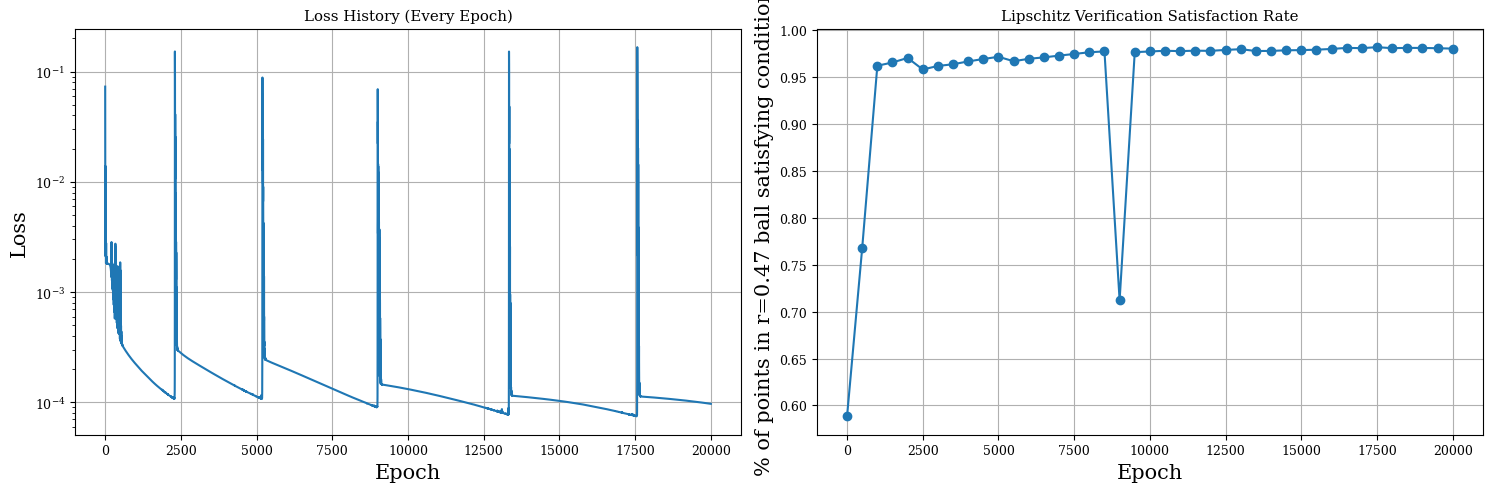

In [ ]:
# @title 7. Plot Training and Verification Results (Modified for Full History)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- 代码修改 START ---
# Plot Loss - 直接绘制loss_history列表，不带'o'标记
ax1.plot(loss_history)
# --- 代码修改 END ---

ax1.set_title('Loss History (Every Epoch)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_yscale('log')
ax1.grid(True)

# Plot Verification Rate - 验证率仍然是每500个epoch记录一次
epochs_recorded = np.arange(0, len(verification_history) * 500, 500)
ax2.plot(epochs_recorded, verification_history, 'o-')
ax2.set_title('Lipschitz Verification Satisfaction Rate')
ax2.set_xlabel('Epoch')
ax2.set_ylabel(f'% of points in r={VERIFICATION_RADIUS} ball satisfying condition')
ax2.grid(True)

plt.tight_layout()
plt.show()

<>:102: SyntaxWarning: invalid escape sequence '\m'
<>:105: SyntaxWarning: invalid escape sequence '\m'
<>:125: SyntaxWarning: invalid escape sequence '\d'
<>:128: SyntaxWarning: invalid escape sequence '\d'
<>:102: SyntaxWarning: invalid escape sequence '\m'
<>:105: SyntaxWarning: invalid escape sequence '\m'
<>:125: SyntaxWarning: invalid escape sequence '\d'
<>:128: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2016/427817827.py:102: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_title("Neural Lyapunov Function $V(\mathbf{x})$")
/tmp/ipykernel_2016/427817827.py:105: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_zlabel("$V(\mathbf{x})$")
/tmp/ipykernel_2016/427817827.py:125: SyntaxWarning: invalid escape sequence '\d'
  ax2.set_title("Lie Derivative $\dot{V}(\mathbf{x})$")
/tmp/ipykernel_2016/427817827.py:128: SyntaxWarning: invalid escape sequence '\d'
  ax2.set_zlabel("$\dot{V}(\mathbf{x})$")


✅ 成功从 Lipschitz_VSM_GP.pt 加载模型权重！
🔄 重新计算的 Threshold = -0.003065 (L_v=3.6797, L_f=1.5060)


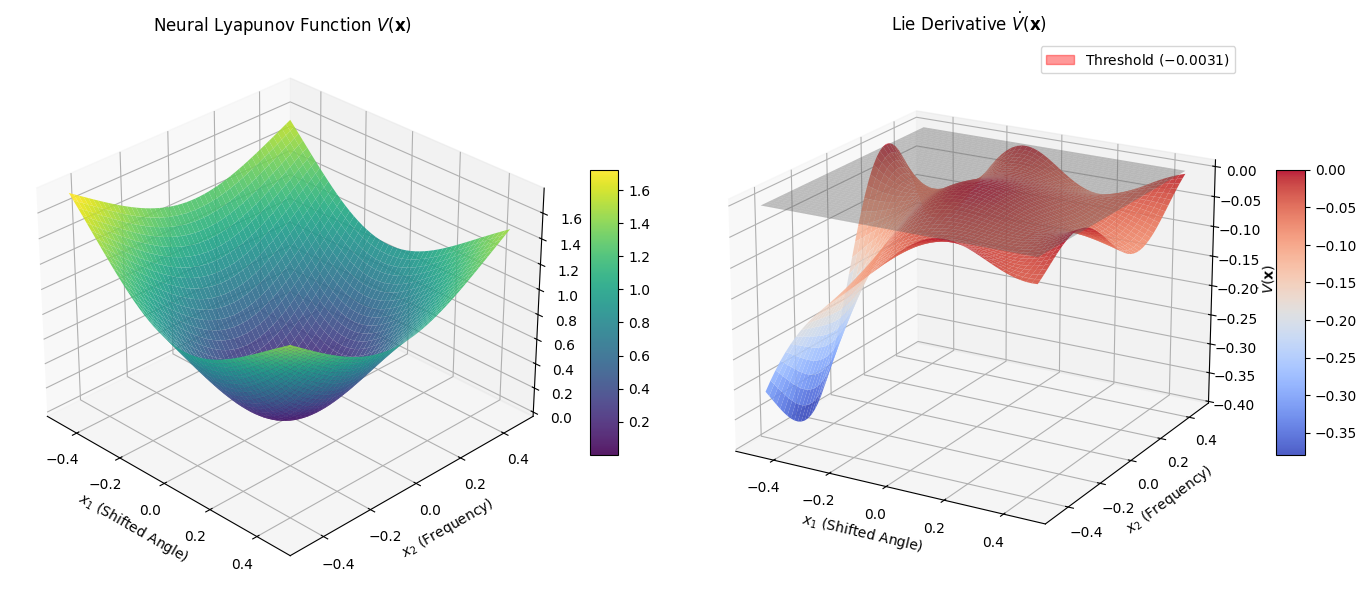

In [ ]:
# ---------- Block 4: Visualization (3D Surface with Threshold Plane) ----------
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches # 用于创建图例
import numpy as np
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. 系统参数与动力学函数 (确保在当前环境中可用)
Pm, M, D, K = 2.0, 1.0, 0.1, 2.5
delta_s = np.arcsin(Pm / K)

def f_value(x):
    x1, x2 = x[:, 0:1], x[:, 1:2]
    dx1 = x2
    dx2 = (Pm - K * torch.sin(x1 + delta_s) - D * x2) / M
    return torch.cat([dx1, dx2], dim=1)

def linearize_dynamics(f_func, x0_tensor):
    A = torch.autograd.functional.jacobian(f_func, x0_tensor)
    return A.squeeze()

# 2. 重新定义与你保存时一模一样的模型架构
D_IN = 2          # VSM 系统的状态维度 (x1, x2)
H1 = 16           # 隐藏层神经元个数
D_PHI_OUT = 2     # phi(x) 的输出维度

class LyapunovNetwork(nn.Module):
    def __init__(self, d_in, h1, d_out):
        super(LyapunovNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, h1),
            nn.Tanh(),
            nn.Linear(h1, h1),
            nn.Tanh(),
            nn.Linear(h1, d_out)
        )

    def forward(self, x):
        phi = self.net(x)
        V = torch.sum(phi**2, dim=1, keepdim=True)
        return V

# 3. 实例化模型并导入保存的权重
model = LyapunovNetwork(D_IN, H1, D_PHI_OUT).to(device)

MODEL_PATH = "Lipschitz_VSM_GP.pt"
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
print(f"✅ 成功从 {MODEL_PATH} 加载模型权重！")
model.eval()

VERIFICATION_RADIUS = 0.47

# 4. Generate grid points
plot_res = 50
axis_plot = np.linspace(-VERIFICATION_RADIUS, VERIFICATION_RADIUS, plot_res)
X1, X2 = np.meshgrid(axis_plot, axis_plot)
X_plot_points = np.stack([X1.ravel(), X2.ravel()], axis=1)
X_plot_tensor = torch.tensor(X_plot_points, dtype=torch.float32).to(device)

# 5. Compute V(x) purely for plotting
with torch.no_grad():
    V_plot = model(X_plot_tensor).cpu().numpy().reshape(plot_res, plot_res)

# 6. Compute \dot{V}(x) which REQUIRES gradients
X_plot_tensor.requires_grad_(True)
V_for_grad = model(X_plot_tensor)
grad_V_plot = torch.autograd.grad(
    V_for_grad, X_plot_tensor, grad_outputs=torch.ones_like(V_for_grad), create_graph=False
)[0]

with torch.no_grad():
    f_plot = f_value(X_plot_tensor)
    V_dot_plot = torch.sum(grad_V_plot * f_plot, dim=1).detach().cpu().numpy().reshape(plot_res, plot_res)

# ================= 核心修改部分：重新计算 Threshold =================
GRID_DENSITY = 4000 # 这里保持你训练时的网格密度，以保证阈值真实性
TAU = 2 * VERIFICATION_RADIUS * np.sqrt(D_IN) / GRID_DENSITY

# 计算系统 Lipschitz (L_f)
x_0 = torch.zeros([1, D_IN]).to(device)
A_matrix = linearize_dynamics(f_value, x_0)
L_f = torch.linalg.norm(A_matrix, ord=2).item()

# 从当前模型梯度中计算网络 Lipschitz (L_v)
L_v = torch.max(torch.norm(grad_V_plot, p=2, dim=1)).item()

# 计算最终严格的安全阈值
threshold = -L_v * (1 + L_f) * TAU
print(f"🔄 重新计算的 Threshold = {threshold:.6f} (L_v={L_v:.4f}, L_f={L_f:.4f})")
# ====================================================================

# 7. 3D Plotting
fig = plt.figure(figsize=(14, 6))

# Plot V(x) 3D Surface
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X1, X2, V_plot, cmap='viridis', edgecolor='none', alpha=0.9)
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)
ax1.set_title("Neural Lyapunov Function $V(\mathbf{x})$")
ax1.set_xlabel("$x_1$ (Shifted Angle)")
ax1.set_ylabel("$x_2$ (Frequency)")
ax1.set_zlabel("$V(\mathbf{x})$")
ax1.view_init(elev=30, azim=-45)

# Plot \dot{V}(x) 3D Surface
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X1, X2, V_dot_plot, cmap='coolwarm', edgecolor='none', alpha=0.9)
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)

# ================= 绘制平面与图例 =================

# 2. 绘制 Lipschitz Threshold 平面 (红色)
threshold_plane = np.full_like(V_dot_plot, threshold)
ax2.plot_surface(X1, X2, threshold_plane, color='gray', alpha=0.4)

# 3. 添加图例，明确区分两个平面
# zero_proxy = mpatches.Patch(color='gray', alpha=0.2, label='Zero Plane ($0$)')
thresh_proxy = mpatches.Patch(color='red', alpha=0.4, label=f'Threshold (${threshold:.4f}$)')
ax2.legend(handles=[thresh_proxy], loc='upper right')
# ==================================================

ax2.set_title("Lie Derivative $\dot{V}(\mathbf{x})$")
ax2.set_xlabel("$x_1$ (Shifted Angle)")
ax2.set_ylabel("$x_2$ (Frequency)")
ax2.set_zlabel("$\dot{V}(\mathbf{x})$")
ax2.view_init(elev=20, azim=-60) # 稍微调低仰角，更容易看清平面之间的上下关系

plt.tight_layout()
plt.show()

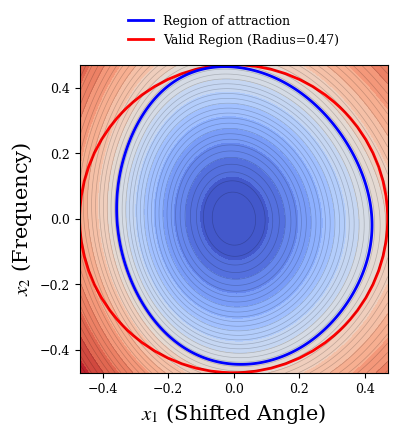

In [ ]:
# ---------- Block 5: TPEL-Style 2D Contour Plot for ROA ----------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import torch
import logging

# 将 matplotlib 的字体管理器的日志级别设置为 ERROR，消除不必要的 Warning
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# --- 0. 全局字体与样式设置 (IEEE TPEL 风格) ---
plt.rcParams['font.family'] = 'Dejavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['mathtext.fontset'] = 'stix'

model.eval()

# --- 1. 准备绘图网格并计算 V(x) 值 ---
# 设定画图范围，稍微比 VERIFICATION_RADIUS 大一点，方便看清边界
plot_limit = VERIFICATION_RADIUS
plot_res = 200 # 使用密集的网格让等高线平滑
axis_range = np.linspace(-plot_limit, plot_limit, plot_res)
X1, X2 = np.meshgrid(axis_range, axis_range)

# 对于当前的2维系统，直接将 X1 和 X2 堆叠 (不需要 X3)
grid_points = np.stack([X1.ravel(), X2.ravel()], axis=1)
grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)

# 使用训练好的模型计算 V(x)
with torch.no_grad():
    V_vals = model(grid_tensor).cpu().numpy().reshape(X1.shape)

# --- 2. 绘制 2D 等高线图 ---
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

# -------------------------------------------------------------
# [可调项] 您可以修改 c_level_to_plot 的值，来寻找恰好包含在红圈内
# 且满足 \dot{V} < 0 的最大 ROA 边界
c_level_to_plot = 0.9
# -------------------------------------------------------------

# 绘制背景：V(x) 的填充等高线图
c1 = ax.contourf(X1, X2, V_vals, levels=20, cmap='coolwarm')
# 可选：如果觉得 colorbar 占用空间，可以注释掉下面这行
# fig.colorbar(c1, ax=ax)

# 绘制细的黑色等高线作为底纹背景（保留了你代码中的细节）
ax.contour(X1, X2, V_vals, levels=50, linewidths=0.5, colors='k', alpha=0.2)

# 绘制你指定的 V(x) = c_level 边界线 (深蓝色加粗)
ax.contour(X1, X2, V_vals - c_level_to_plot, levels=[0], colors='blue', linewidths=2)

# 绘制红色的圆圈作为 Lipschitz 验证的安全基准区域
valid_region_circle = plt.Circle((0, 0), VERIFICATION_RADIUS, color='r', linestyle='-', linewidth=2, fill=False)
ax.add_artist(valid_region_circle)

# # 绘制示例的大扰动测试点 (根据你的 HIL 测试或仿真数据修改坐标)
# ax.scatter(-0.18, -0.28, color='yellow', marker='^', s=50, zorder=5, edgecolors='black')
# ax.scatter(0.06, -0.09, color='red', marker='o', s=30, zorder=5, edgecolors='black')

# 设置图表属性
ax.set_xlabel('$x_1$ (Shifted Angle)')
ax.set_ylabel('$x_2$ (Frequency)')
ax.set_aspect('equal', adjustable='box')

# 创建图例 (完全遵循你的放置风格，置于图表正上方)
blue_line = mlines.Line2D([], [], color='blue', linewidth=2, label='Region of attraction')
red_line = mlines.Line2D([], [], color='red', linestyle='-', linewidth=2, label=f'Valid Region (Radius={VERIFICATION_RADIUS})')

ax.legend(handles=[blue_line, red_line], loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=1, frameon=False)

# 保存为 600 DPI 的高分辨率图片用于论文
# plt.savefig('ROA_Plot_2D_600dpi.png', dpi=600, bbox_inches='tight', pad_inches=0.1, format='png')

plt.show()

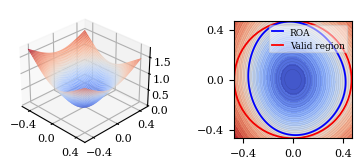

In [ ]:
# 引入 GridSpec
from matplotlib.gridspec import GridSpec
# --- Times New Roman, 9 pt everywhere (text + math) ---
plt.rcParams['font.family']      = 'Dejavu Serif'
plt.rcParams['font.serif']       = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'          # Times-matched math symbols
for _k in ['font.size', 'axes.labelsize', 'axes.titlesize',
           'xtick.labelsize', 'ytick.labelsize', 'legend.fontsize']:
    plt.rcParams[_k] = 9
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
# 1. 使用 layout='constrained' 替代 tight_layout，这在处理 2D/3D 混合布局时表现更好
fig = plt.figure(figsize=(3.5, 1.75), layout='constrained')

# 2. 使用 GridSpec 给 3D 图分配更多的宽度比例 (例如 1.2 : 1)
gs = GridSpec(1, 2, figure=fig, width_ratios=[1.2, 1], wspace=0.15)

# (a) Neural Lyapunov function — 3D surface
axa = fig.add_subplot(gs[0, 0], projection='3d') # 使用 GridSpec 定位
axa.plot_surface(X1a, X2a, Va, cmap='coolwarm', edgecolor='none', alpha=1,
                 rcount=res_a, ccount=res_a)
axa.set_xticks([-0.4, 0, 0.4]); axa.set_yticks([-0.4, 0, 0.4])
axa.zaxis.set_major_locator(plt.MaxNLocator(4))
axa.tick_params(pad=-3)
axa.view_init(elev=30, azim=-45)

# 3. 压缩 3D 图的 Z 轴显示比例，让它在视觉上显得更宽更大
axa.set_box_aspect(aspect=(1, 1, 0.75))

# (b) Region of attraction — 2D contour
axb = fig.add_subplot(gs[0, 1]) # 使用 GridSpec 定位
axb.contourf(X1b, X2b, Vb, levels=20, cmap='coolwarm')
axb.contour(X1b, X2b, Vb, levels=50, linewidths=0.3, colors='k', alpha=0.18)
axb.contour(X1b, X2b, Vb - c_level, levels=[0], colors='blue', linewidths=1.3)
axb.add_artist(plt.Circle((0, 0), R, color='r', linewidth=1.3, fill=False))
axb.set_xticks([-0.4, 0, 0.4]); axb.set_yticks([-0.4, 0, 0.4])
axb.set_aspect('equal', adjustable='box')

_roa = mlines.Line2D([], [], color='blue', lw=1.3, label='ROA')
_val = mlines.Line2D([], [], color='red',  lw=1.3, label='Valid region')
axb.legend(handles=[_roa, _val], loc='upper right', fontsize=6.5,
           frameon=True, framealpha=0.5, borderpad=0.25, handlelength=1.2)

# 4. 删除你原本的 plt.tight_layout() 以及后续的 set_position 手动调整代码！
# plt.tight_layout(pad=0.3) <--- 删除
# fig.canvas.draw() <--- 删除
# _pb = axb.get_position() <--- 删除
# axa.set_position(...) <--- 删除
plt.savefig('VSM_Lyapunov_ROA_singlecol.png', dpi=300)
plt.show()

<>:198: SyntaxWarning: invalid escape sequence '\m'
<>:198: SyntaxWarning: invalid escape sequence '\l'
<>:198: SyntaxWarning: invalid escape sequence '\m'
<>:198: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_698/1427328081.py:198: SyntaxWarning: invalid escape sequence '\m'
  blue_line = mlines.Line2D([], [], color='blue', linewidth=2, linestyle='--', label=f'Theoretical ROA ($V(\mathbf{{x}}) \leq {c_level_to_plot}$)')
/tmp/ipykernel_698/1427328081.py:198: SyntaxWarning: invalid escape sequence '\l'
  blue_line = mlines.Line2D([], [], color='blue', linewidth=2, linestyle='--', label=f'Theoretical ROA ($V(\mathbf{{x}}) \leq {c_level_to_plot}$)')


🚀 开始通过 GP 与 EMT 仿真延拓 ROA...
--- 迭代 1/4 ---
  查询点 [-1.05, -0.04] -> 仿真标签: 0.0
  查询点 [-1.05, -0.06] -> 仿真标签: 0.0
  查询点 [-1.05, -0.08] -> 仿真标签: 0.0
  查询点 [-1.05, -0.11] -> 仿真标签: 0.0
  查询点 [0.01, -1.10] -> 仿真标签: 0.0
--- 迭代 2/4 ---
  查询点 [-0.11, 1.03] -> 仿真标签: 0.0
  查询点 [0.06, 1.03] -> 仿真标签: 0.0
  查询点 [-0.13, 1.03] -> 仿真标签: 0.0
  查询点 [-0.16, 1.03] -> 仿真标签: 0.0
  查询点 [-0.18, 1.03] -> 仿真标签: 0.0
--- 迭代 3/4 ---
  查询点 [0.93, 0.08] -> 仿真标签: 0.0
  查询点 [0.93, 0.11] -> 仿真标签: 0.0
  查询点 [0.91, 0.23] -> 仿真标签: 0.0
  查询点 [0.93, 0.13] -> 仿真标签: 0.0
  查询点 [0.93, 0.16] -> 仿真标签: 0.0
--- 迭代 4/4 ---
  查询点 [-0.45, -0.64] -> 仿真标签: 0.0
  查询点 [-0.57, -0.55] -> 仿真标签: 0.0
  查询点 [-0.55, -0.57] -> 仿真标签: 0.0
  查询点 [-0.52, -0.59] -> 仿真标签: 0.0
  查询点 [-0.50, -0.62] -> 仿真标签: 0.0


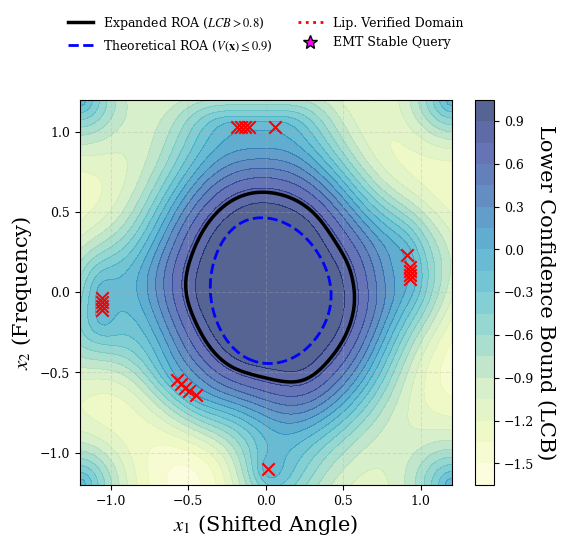

In [ ]:
# ---------- Block 6: GP Active Learning & LCB Expanded ROA (TPEL Style) ----------
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.integrate import solve_ivp
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
import logging
import warnings

# 忽略警告并设置 TPEL 字体
warnings.filterwarnings('ignore')
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
plt.rcParams['font.family'] = 'Dejavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['mathtext.fontset'] = 'stix'
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 1. 物理系统与模型重构导入
# ==========================================
Pm, M, D, K = 2.0, 1.0, 0.1, 2.5
delta_s = np.arcsin(Pm / K)
x1_uep = np.pi - 2 * delta_s

def system_dynamics(t, x):
    x1, x2 = x
    return [x2, (Pm - K * np.sin(x1 + delta_s) - D * x2) / M]

class LyapunovNetwork(nn.Module):
    def __init__(self, d_in, h1, d_out):
        super(LyapunovNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, h1), nn.Tanh(),
            nn.Linear(h1, h1), nn.Tanh(),
            nn.Linear(h1, d_out)
        )
    def forward(self, x):
        phi = self.net(x)
        return torch.sum(phi**2, dim=1, keepdim=True)

model = LyapunovNetwork(2, 16, 2).to(device)
MODEL_PATH = "Lipschitz_VSM_GP.pt"  # 确保文件名一致
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

# ==========================================
# 2. 带有“轨迹遗传法则”的 EMT Oracle
# ==========================================
def emt_oracle_with_traj(x0, t_max=15.0):
    """
    不仅返回稳定标签，还返回轨迹采样点。
    """
    sol = solve_ivp(system_dynamics, (0, t_max), x0, max_step=0.1)
    x1_final, x2_final = sol.y[0, -1], sol.y[1, -1]

    # 轨迹降采样（提取沿途的5个点作为免费安全数据遗传给GP）
    traj_points = sol.y[:, ::max(1, sol.y.shape[1]//5)].T

    if np.abs(x1_final) < 0.2 and np.abs(x2_final) < 0.2 and np.max(np.abs(sol.y[0])) < 3.0:
        return 1.0, traj_points
    return 0.0, [x0] # 若发散，仅将起点标为危险

# ==========================================
# 3. 提取真实 Neural Lyapunov ROA 作为冷启动数据
# ==========================================
VERIFICATION_RADIUS = 0.47
c_level_to_plot = 0.9

# 我们把探索视野放大到 1.2，看看外部能扩展多少
plot_limit = 1.2
grid_res = 100
axis_range = np.linspace(-plot_limit, plot_limit, grid_res)
X1, X2 = np.meshgrid(axis_range, axis_range)
grid_points = np.stack([X1.ravel(), X2.ravel()], axis=1)
grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)

with torch.no_grad():
    V_vals = model(grid_tensor).cpu().numpy().flatten()

X_train, y_train = [], []

# 严谨的数学地基：只有 V(x) <= 0.9 且在验证半径内的点，才是绝对安全的
safe_mask = (V_vals <= c_level_to_plot) & (np.linalg.norm(grid_points, axis=1) <= VERIFICATION_RADIUS)
safe_candidates = grid_points[safe_mask]

# 从这个真实的异形安全区内随机抽取 150 个点作为基础正样本
np.random.shuffle(safe_candidates)
for pt in safe_candidates[:150]:
    X_train.append(pt)
    y_train.append(1.0)

# 在物理边界添加极少数发散样本防爆
danger_points = [[plot_limit, plot_limit], [plot_limit, -plot_limit], [-plot_limit, -plot_limit], [-plot_limit, plot_limit]]
for dp in danger_points:
    X_train.append(dp)
    y_train.append(0.0)

X_train, y_train = np.array(X_train), np.array(y_train)

# ==========================================
# 4. GP 主动学习与 LCB 外扩
# ==========================================
# 注意：这里使用 Regressor，因为它能提供极其严格的方差 std
kernel = C(1.0, (1e-3, 1e3)) * RBF(0.5, (1e-2, 1e2))
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3, alpha=1e-4)

active_iterations = 4
queries_per_iter = 5
queried_plot_points = []

print("🚀 开始通过 GP 与 EMT 仿真延拓 ROA...")
for i in range(active_iterations):
    gpr.fit(X_train, y_train)

    # 预测并获取不确定性 (std)
    mu, std = gpr.predict(grid_points, return_std=True)

    # 采集策略：在“均值看似安全 (mu > 0.8)” 但“极其不确定 (std 最大)” 的地方开盲盒
    candidate_mask = (mu > 0.8) & (~safe_mask)
    if not np.any(candidate_mask): break

    uncertainties = std.copy()
    uncertainties[~candidate_mask] = -1 # 排除安全区和已确定危险区

    # 【修复处】：刚才错写成了 uncertainty，修正为 uncertainties
    high_risk_indices = np.argsort(uncertainties)[-queries_per_iter:] # 挑方差最大的

    print(f"--- 迭代 {i+1}/{active_iterations} ---")
    for idx in high_risk_indices:
        x_query = grid_points[idx]
        is_stable, traj = emt_oracle_with_traj(x_query)

        queried_plot_points.append((x_query, is_stable))
        print(f"  查询点 [{x_query[0]:.2f}, {x_query[1]:.2f}] -> 仿真标签: {is_stable}")

        # 轨迹遗传：将一次仿真得到的一整条安全轨迹加入知识库
        for pt in traj:
            X_train = np.vstack([X_train, pt])
            y_train = np.append(y_train, is_stable)

# 最终拟合，计算严格置信下界 (LCB)
gpr.fit(X_train, y_train)
mu, std = gpr.predict(grid_points, return_std=True)

# 核心：计算 LCB。惩罚 3 倍的标准差 (对应 99.7% 的物理置信度)
LCB = mu - 3 * std
LCB_grid = LCB.reshape(grid_res, grid_res)
V_grid = V_vals.reshape(grid_res, grid_res)

# ==========================================
# 5. TPEL 风格高级可视化
# ==========================================
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

# 绘制背景：LCB 置信度热力图
c1 = ax.contourf(X1, X2, LCB_grid, levels=20, cmap='YlGnBu', alpha=0.7)
cbar = fig.colorbar(c1, ax=ax)
cbar.set_label('Lower Confidence Bound (LCB)', rotation=270, labelpad=15)

# (A) 绘制数学内圈：真实的 Neural Lyapunov ROA
ax.contour(X1, X2, V_grid - c_level_to_plot, levels=[0], colors='blue', linewidths=2, linestyles='--')

# (B) 绘制物理外圈：LCB 极度保守验证边界 (例如 LCB > 0.85 即认为 100% 安全)
ax.contour(X1, X2, LCB_grid - 0.8, levels=[0], colors='black', linewidths=2.5)

# 画出 Lipschitz 验证圆 (供对比)
# valid_region_circle = plt.Circle((0, 0), VERIFICATION_RADIUS, color='r', linestyle=':', linewidth=2, fill=False)
# ax.add_artist(valid_region_circle)

# 画出 UEP (不稳定平衡点) 参照
ax.plot(x1_uep, 0, 'kX', markersize=10, zorder=5)

# 标记所有呼叫过 EMT 的高危查询点
for pt, stable in queried_plot_points:
    color = 'magenta' if stable == 1.0 else 'red'
    marker = '*' if stable == 1.0 else 'x'
    ax.scatter(pt[0], pt[1], color=color, marker=marker, s=80, edgecolors='black' if stable==1.0 else 'none', zorder=6)

ax.set_xlabel('$x_1$ (Shifted Angle)')
ax.set_ylabel('$x_2$ (Frequency)')
ax.set_xlim(-plot_limit, plot_limit)
ax.set_ylim(-plot_limit, plot_limit)

# 图例设置
blue_line = mlines.Line2D([], [], color='blue', linewidth=2, linestyle='--', label=f'Theoretical ROA ($V(\mathbf{{x}}) \leq {c_level_to_plot}$)')
black_line = mlines.Line2D([], [], color='black', linewidth=2.5, label='Expanded ROA ($LCB > 0.8$)')
red_circle = mlines.Line2D([], [], color='red', linestyle=':', linewidth=2, label=f'Lip. Verified Domain')
star_marker = mlines.Line2D([], [], color='magenta', marker='*', linestyle='None', markersize=10, markeredgecolor='k', label='EMT Stable Query')

ax.legend(handles=[black_line, blue_line, red_circle, star_marker], loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2, frameon=False)

plt.grid(True, linestyle='--', alpha=0.3)
# plt.savefig('Expanded_ROA_LCB_TPEL.png', dpi=600, bbox_inches='tight', pad_inches=0.1)
plt.show()

🔭  UNCERTAINTY-DRIVEN ACO EXPLORATION  (Paradigm v3: NO Vdot)
Rounds                  : 20 (early stop after 2 quiet rounds)
ACO seeds per round     : 3
Hotspots queried / rd   : 10
Min-distance separation : 0.1
Uncertainty tolerance   : std >= 0.05
Search annulus          : 0.05 <= ||x|| <= 0.7
----------------------------------------------------------------------------
[Round  1]  hotspots: 11813  max_std=0.139  mean_grid_std=0.163  | queried 10: stab=10 unst=0 +70 pts (total 244)
  x=[-0.594,+0.371] std=0.139 -> STABLE
  x=[-0.534,+0.452] std=0.133 -> STABLE
  x=[-0.640,+0.282] std=0.133 -> STABLE
  x=[-0.463,+0.524] std=0.120 -> STABLE
  x=[-0.674,+0.187] std=0.120 -> STABLE
  x=[+0.501,-0.489] std=0.116 -> STABLE
  x=[+0.425,-0.555] std=0.112 -> STABLE
  x=[+0.566,-0.411] std=0.112 -> STABLE
  x=[-0.694,+0.089] std=0.107 -> STABLE
  x=[+0.494,+0.494] std=0.107 -> STABLE
[Round  2]  hotspots: 11608  max_std=0.087  mean_grid_std=0.143  | queried 10: stab=10 unst=0 +70 pts (total 314

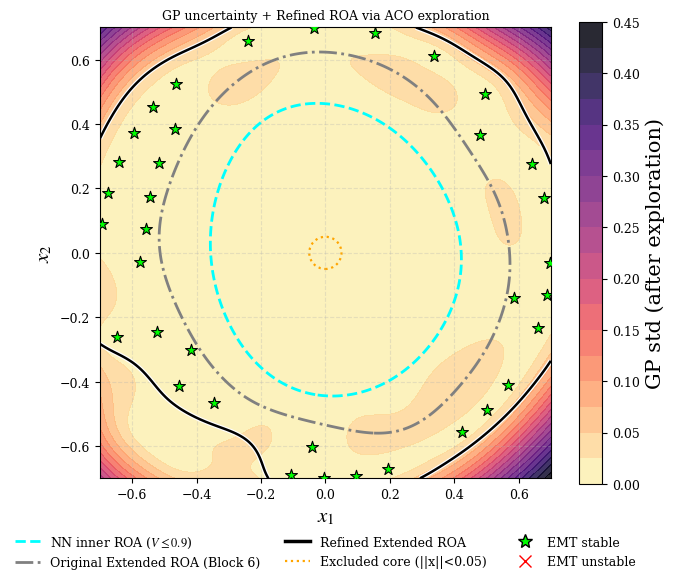

In [ ]:
# ==========================================================================
# Block X+3 — Uncertainty-Driven ACO Exploration  (Paradigm v3)
# --------------------------------------------------------------------------
# Run this directly after Block 6.
#
# PARADIGM SHIFT vs. previous versions:
#   OLD:  ACO maximized Vdot(x)  -> finds "Lyapunov counterexamples"
#         -> often pseudo-CEs in extrapolated regions where the NN's
#            gradient distorts
#   NEW:  ACO maximizes GP std(x) -> finds "uncertainty hotspots"
#         -> these are the regions where the GP genuinely doesn't know
#         -> EMT verdicts on hotspots become high-information samples
#
# Key consequences:
#   * NO Lyapunov derivative anywhere in the loop.
#   * NO LCB constraint on the search region — ants roam the whole annulus
#     INNER_RADIUS <= ||x|| <= OUTER_LIMIT.  This lets them probe BOTH
#     sides of the current ROA boundary, which is exactly where new
#     information lives.
#   * Natural early stop: when the GP becomes confident enough that
#     no point in the annulus has std >= UNCERTAINTY_TOL, the loop ends.
# ==========================================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
# ==========================================================================
# Override Block 6's EMT oracle with the SAME criteria as Block 8 ground
# truth.  Block 6's version used t_max=15s + an overshoot check that
# misclassified large-amplitude-but-stable swings as unstable, which in
# turn poisoned the GP training labels in our closed-loop refinement.
# --------------------------------------------------------------------------
from scipy.integrate import solve_ivp

def _diverge_event(t, x):
    return 5.0 - np.max(np.abs(x))
_diverge_event.terminal = True

def emt_oracle_with_traj(x0, t_max=100.0):
    """
    Ground-truth EMT oracle, identical to Block 8's logic:
      * Integrate to t_max=100s with an early-termination event when |x|>5.
      * Stable iff (a) the divergence event was NOT triggered, AND
                   (b) the final state lies within |x_i| < 0.2 of origin.
      * No overshoot check — VSM's low damping (D=0.1) produces large but
        stable angular swings that the old check spuriously rejected.
    Returns (label, trajectory_points) for use as GP training data.
    """
    sol = solve_ivp(system_dynamics, (0.0, t_max), x0, method='RK45',
                    events=_diverge_event, max_step=0.1)
    diverged = (sol.status == 1)
    x1_final, x2_final = sol.y[0, -1], sol.y[1, -1]
    is_stable = (not diverged) and (abs(x1_final) < 0.2) \
                              and (abs(x2_final) < 0.2)

    # Subsample trajectory for the "trajectory inheritance" trick
    n_pts = sol.y.shape[1]
    step  = max(1, n_pts // 5)
    traj  = sol.y[:, ::step].T
    if is_stable:
        return 1.0, traj
    else:
        # On divergence, only the seed point is reliably labeled unstable
        return 0.0, [x0]

# ---- Closed-loop knobs ------------------------------------------------
N_EXPLORATION_ROUNDS  = 20
N_ACO_SEEDS_PER_ROUND = 3
TOP_K_TO_QUERY        = 10          # how many hotspots to send to EMT/round
DIVERSITY_RADIUS      = 0.1      # ~ kernel length / 3
UNCERTAINTY_TOL       = 0.05       # std below this is "GP knows enough"
EARLY_STOP_QUIET_RD   = 2          # stop after N rounds with no hotspots
SNAPSHOT_EVERY        = 4

# ---- Per-round ACO knobs ----------------------------------------------
LCB_THRESHOLD   = 0.80             # used ONLY for plotting the ROA boundary
INNER_RADIUS    = 0.05             # exclude tiny disk around origin
OUTER_LIMIT     = 0.7              # outer radius of exploration annulus
ARCHIVE_SIZE    = 50
N_ANTS          = 40
N_ITERS         = 100
Q_LOCALITY      = 0.10
XI_EVAPORATION  = 0.85
ACO_SEED_BASE   = 0
# -----------------------------------------------------------------------


# ==================  Annulus geometry helpers  ==================
def in_annulus(x_np, r_min, r_max):
    n = np.linalg.norm(x_np, axis=1)
    return (n >= r_min) & (n <= r_max)


def project_into_annulus(x, r_min, r_max, rng):
    """
    Pull stray ants back into the annulus  r_min <= ||x|| <= r_max.
    No LCB constraint — ants roam freely on both sides of the GP boundary.
    """
    x = x.copy()
    norms = np.linalg.norm(x, axis=1, keepdims=True).clip(min=1e-12)
    # outer clip
    far = norms.squeeze(-1) > r_max
    if far.any():
        x[far] = x[far] * (r_max / norms[far]) * 0.999
    # push out of inner exclusion disk
    norms = np.linalg.norm(x, axis=1, keepdims=True).clip(min=1e-12)
    too_close = norms.squeeze(-1) < r_min
    if too_close.any():
        zero_like = norms.squeeze(-1) < 1e-8
        if zero_like.any():
            d = rng.standard_normal((int(zero_like.sum()), 2))
            d /= np.linalg.norm(d, axis=1, keepdims=True) + 1e-12
            x[zero_like] = d * (r_min * 1.05)
            norms = np.linalg.norm(x, axis=1, keepdims=True).clip(min=1e-12)
            too_close = norms.squeeze(-1) < r_min
        if too_close.any():
            x[too_close] = x[too_close] * (r_min * 1.05 / norms[too_close])
    return x, in_annulus(x, r_min, r_max)


# ==================  Continuous ACO_R explorer  ==================
class ContinuousACO_Explorer:
    """
    Pheromone model: rank-ordered ARCHIVE of k elite solutions.
    Search domain: geometric annulus { r_min <= ||x|| <= r_max }.
    Objective:     MAXIMIZE  GP predictive std(x).
    Hotspot:       any sampled x with std(x) >= uncertainty_tol.
    """
    def __init__(self, gpr, r_min, r_max,
                 archive_size, n_ants, n_iters, q, xi, seed,
                 uncertainty_tol):
        self.gpr = gpr
        self.r_min, self.r_max = r_min, r_max
        self.k, self.m, self.T = archive_size, n_ants, n_iters
        self.q, self.xi, self.dim = q, xi, 2
        self.unc_tol = uncertainty_tol
        self.rng = np.random.default_rng(seed)
        self._compute_weights()

    def _compute_weights(self):
        ranks = np.arange(1, self.k + 1)
        w = (1.0 / (self.q*self.k*np.sqrt(2*np.pi))) * \
            np.exp(-(ranks-1)**2 / (2.0*(self.q*self.k)**2))
        self.p = w / w.sum()

    # ---- objective: GP predictive std  (NOT Vdot) ----
    def _evaluate(self, x_np):
      mu, std = self.gpr.predict(x_np, return_std=True)
      # Only reward uncertainty in regions the GP thinks might be safe.
      # This focuses exploration on filling gaps INSIDE the candidate ROA,
      # rather than chasing high-std points in obviously unstable far-field.
      score = std * (mu > 0.5).astype(float)
      return score

    # ---- archive seeding: uniform over the annulus ----
    def _seed_archive(self, n):
        out, filled, attempts = np.zeros((n, 2)), 0, 0
        while filled < n and attempts < 200:
            attempts += 1
            need = (n - filled) * 3
            r = np.sqrt(self.rng.uniform(self.r_min**2, self.r_max**2, need))
            th = self.rng.uniform(0, 2*np.pi, need)
            cand = np.stack([r*np.cos(th), r*np.sin(th)], axis=1)
            cp, ok = project_into_annulus(cand, self.r_min, self.r_max, self.rng)
            kp = cp[ok]
            take = min(n - filled, kp.shape[0])
            if take > 0:
                out[filled:filled+take] = kp[:take]
                filled += take
        return out[:filled] if filled > 0 else None

    def _sample_ants(self, archive_x):
        guides = self.rng.choice(self.k, size=self.m, p=self.p)
        cand = np.empty((self.m, self.dim))
        for i, j in enumerate(guides):
            mu_j = archive_x[j]
            sigma_j = self.xi * np.abs(archive_x - mu_j).sum(0) \
                      / max(self.k-1, 1)
            sigma_j = np.maximum(sigma_j, 1e-4)
            cand[i] = mu_j + self.rng.normal(0, 1, self.dim) * sigma_j
        return project_into_annulus(cand, self.r_min, self.r_max, self.rng)

    def run(self):
        X = self._seed_archive(self.k)
        if X is None or X.shape[0] < 2:
            return {"empty": True, "hotspots": [],
                    "best_x": None, "best_std": -np.inf,
                    "archive_x": np.zeros((0,2))}
        if X.shape[0] < self.k:
            self.k = X.shape[0]
            self._compute_weights()
        f = self._evaluate(X)
        order = np.argsort(-f); X, f = X[order], f[order]
        hotspots = []
        for _ in range(self.T):
            cand, ok = self._sample_ants(X); cand = cand[ok]
            if cand.shape[0] == 0: continue
            f_cand = self._evaluate(cand)
            mask = f_cand >= self.unc_tol
            for x_h, sd in zip(cand[mask], f_cand[mask]):
                hotspots.append((x_h.copy(), float(sd)))
            X = np.vstack([X, cand]); f = np.concatenate([f, f_cand])
            order = np.argsort(-f)[:self.k]; X, f = X[order], f[order]
        return {"empty": False,
                "best_x": X[0], "best_std": float(f[0]),
                "archive_x": X, "hotspots": hotspots}


# ====================  Diverse top-K selection  =====================
def select_diverse_topk(hotspots, k, min_dist):
    """Pick k hotspots: highest std first, with min spatial separation."""
    if not hotspots: return []
    s = sorted(hotspots, key=lambda t: -t[1])
    chosen = []
    for x, sd in s:
        if all(np.linalg.norm(x - c[0]) >= min_dist for c in chosen):
            chosen.append((x, sd))
        if len(chosen) >= k: break
    return chosen


# =====================  Exploration driver  =========================
print("=" * 76)
print("🔭  UNCERTAINTY-DRIVEN ACO EXPLORATION  (Paradigm v3: NO Vdot)")
print("=" * 76)
print(f"Rounds                  : {N_EXPLORATION_ROUNDS} (early stop after "
      f"{EARLY_STOP_QUIET_RD} quiet rounds)")
print(f"ACO seeds per round     : {N_ACO_SEEDS_PER_ROUND}")
print(f"Hotspots queried / rd   : {TOP_K_TO_QUERY}")
print(f"Min-distance separation : {DIVERSITY_RADIUS}")
print(f"Uncertainty tolerance   : std >= {UNCERTAINTY_TOL}")
print(f"Search annulus          : {INNER_RADIUS} <= ||x|| <= {OUTER_LIMIT}")
print("-" * 76)

# Working copies (Block 6's gpr/X_train/y_train stay untouched for Block 7)
X_exp = X_train.copy(); y_exp = y_train.copy()

def fresh_gpr():
    # PINNED kernel: prevents the GP from re-optimizing the length scale
    # to extreme values across rounds, which would make uncertainty
    # estimates erratic.  (0.25, 1.0) is consistent with Block 6's 0.5.
    kern = C(1.0, (1e-2, 1e2)) * RBF(0.5, (0.25, 1.0))
    return GaussianProcessRegressor(kernel=kern, n_restarts_optimizer=2,
                                    alpha=1e-4, random_state=42)

gpr_exp = fresh_gpr()
gpr_exp.fit(X_exp, y_exp)

# Snapshot the initial GP state for the evolution plot
snapshot_GPs = [(0, gpr_exp.predict(grid_points, return_std=True))]

log_rounds, log_n_hotspots, log_max_std    = [], [], []
log_n_stab,  log_n_unst,    log_n_pts      = [], [], []
log_mean_std_grid                          = []
all_emt_queries  = []        # (x, label, round, std_before)
quiet_streak = 0

for rd in range(1, N_EXPLORATION_ROUNDS + 1):
    # ---- 1. Multi-seed ACO uncertainty exploration ----
    all_hotspots = []; max_std = -np.inf
    for so in range(N_ACO_SEEDS_PER_ROUND):
        aco = ContinuousACO_Explorer(
            gpr=gpr_exp, r_min=INNER_RADIUS, r_max=OUTER_LIMIT,
            archive_size=ARCHIVE_SIZE, n_ants=N_ANTS, n_iters=N_ITERS,
            q=Q_LOCALITY, xi=XI_EVAPORATION,
            seed=ACO_SEED_BASE + rd*100 + so,
            uncertainty_tol=UNCERTAINTY_TOL,
        )
        res = aco.run()
        if res.get("empty", False):
            continue
        all_hotspots.extend(res["hotspots"])
        max_std = max(max_std, res["best_std"])

    n_hot = len(all_hotspots)
    # also record global max std on the plotting grid (sanity check)
    _, std_grid = gpr_exp.predict(grid_points, return_std=True)
    mean_std_grid = float(std_grid.mean())

    log_rounds.append(rd); log_n_hotspots.append(n_hot)
    log_max_std.append(max_std if max_std > -np.inf else 0.0)
    log_mean_std_grid.append(mean_std_grid)

    if n_hot == 0:
        quiet_streak += 1
        log_n_stab.append(0); log_n_unst.append(0); log_n_pts.append(0)
        print(f"[Round {rd:2d}]  No uncertainty hotspots above tol "
              f"{UNCERTAINTY_TOL}. (mean grid std = {mean_std_grid:.3f})")
        if quiet_streak >= EARLY_STOP_QUIET_RD:
            print(f"\n✅ GP confidence saturated for {quiet_streak} "
                  f"consecutive rounds. Stopping.")
            break
        continue
    else:
        quiet_streak = 0

    # ---- 2. Pick top-K diverse hotspots ----
    queries = select_diverse_topk(all_hotspots, TOP_K_TO_QUERY,
                                  DIVERSITY_RADIUS)

    # ---- 3. EMT all queries; ingest labels + trajectories ----
    n_st, n_un, new_pts = 0, 0, 0
    msgs = []
    for x_q, sd_q in queries:
        is_st, traj = emt_oracle_with_traj(x_q.tolist())
        all_emt_queries.append((x_q.copy(), float(is_st), rd, float(sd_q)))
        if is_st > 0.5: n_st += 1
        else:           n_un += 1
        # add the queried point itself
        X_exp = np.vstack([X_exp, x_q.reshape(1,2)])
        y_exp = np.append(y_exp, is_st); new_pts += 1
        # plus trajectory points (Block 6's "trajectory inheritance" trick)
        for pt in traj:
            X_exp = np.vstack([X_exp, np.asarray(pt).reshape(1,2)])
            y_exp = np.append(y_exp, is_st); new_pts += 1
        msgs.append(f"  x=[{x_q[0]:+.3f},{x_q[1]:+.3f}] std={sd_q:.3f} -> "
                    f"{'STABLE' if is_st>0.5 else 'UNSTABLE'}")

    log_n_stab.append(n_st); log_n_unst.append(n_un); log_n_pts.append(new_pts)

    # ---- 4. Refit GP ----
    gpr_exp.fit(X_exp, y_exp)

    # ---- 5. Snapshot ----
    if rd % SNAPSHOT_EVERY == 0 or rd == 1:
        snapshot_GPs.append((rd, gpr_exp.predict(grid_points, return_std=True)))

    print(f"[Round {rd:2d}]  hotspots: {n_hot:5d}  max_std={max_std:.3f}  "
          f"mean_grid_std={mean_std_grid:.3f}  | "
          f"queried {len(queries)}: stab={n_st} unst={n_un} +{new_pts} pts "
          f"(total {len(X_exp)})")
    for m in msgs: print(m)

# Final snapshot
snapshot_GPs.append((rd, gpr_exp.predict(grid_points, return_std=True)))


# =====================  Final exploration check  =========================
print("\n🔬 Final scan: 5-seed ACO sweep on the saturated GP...")
final_hotspots = []; final_max_std = -np.inf
for s in range(5):
    aco = ContinuousACO_Explorer(
        gpr=gpr_exp, r_min=INNER_RADIUS, r_max=OUTER_LIMIT,
        archive_size=ARCHIVE_SIZE, n_ants=N_ANTS, n_iters=N_ITERS*2,
        q=Q_LOCALITY, xi=XI_EVAPORATION, seed=99000 + s,
        uncertainty_tol=UNCERTAINTY_TOL,
    )
    rr = aco.run()
    if rr.get("empty", False): continue
    final_hotspots.extend(rr["hotspots"])
    final_max_std = max(final_max_std, rr["best_std"])

print("=" * 76)
if not final_hotspots:
    print("✅  GP IS WELL-EXPLORED across the annulus.")
    print(f"    5-seed ACO found ZERO hotspots with std >= {UNCERTAINTY_TOL}.")
    print(f"    Worst-case probed std = {final_max_std:.4f}")
else:
    hs_sorted = sorted(final_hotspots, key=lambda t: -t[1])
    distinct = []
    for x_h, sd in hs_sorted:
        if all(np.linalg.norm(x_h - d[0]) > DIVERSITY_RADIUS for d in distinct):
            distinct.append((x_h, sd))
        if len(distinct) >= 10: break
    print(f"⚠️  {len(final_hotspots)} residual hotspots "
          f"(in {len(distinct)} distinct clusters)")
    print( "    Top distinct uncertainty clusters:")
    for x_h, sd in distinct[:8]:
        print(f"      x = [{x_h[0]:+.4f}, {x_h[1]:+.4f}]   std = {sd:.4f}")
print("=" * 76)


# =========================  Visualization  =========================
# Build a self-contained plotting grid (don't rely on Block 6/7 leftovers,
# which may have inconsistent grid_res values).
PLOT_LIM = OUTER_LIMIT
PLOT_RES = 200

_axis    = np.linspace(-PLOT_LIM, PLOT_LIM, PLOT_RES)
_X1, _X2 = np.meshgrid(_axis, _axis)
_grid    = np.stack([_X1.ravel(), _X2.ravel()], axis=1)

# Final hardened GP — predict on our own grid
mu_fin, sd_fin = gpr_exp.predict(_grid, return_std=True)
LCB_final = (mu_fin - 3*sd_fin).reshape(PLOT_RES, PLOT_RES)
STD_final = sd_fin.reshape(PLOT_RES, PLOT_RES)

# Original Block-6 GP — re-predict to guarantee shape match
mu_orig, sd_orig = gpr.predict(_grid, return_std=True)
LCB_orig_plot = (mu_orig - 3*sd_orig).reshape(PLOT_RES, PLOT_RES)

# NN V(x) on our grid
_grid_t = torch.tensor(_grid, dtype=torch.float32).to(device)
with torch.no_grad():
    V_nn_grid = model(_grid_t).cpu().numpy().reshape(PLOT_RES, PLOT_RES)

# Re-evaluate snapshots on the same grid (so all contours align)
snapshot_LCBs_plot = []
for rd_i, _ in snapshot_GPs:
    pass  # we'll just re-fit-predict from logged states below if needed

# Simpler: recompute snapshots from saved (mu, std) but on the right grid.
# Since we stored predictions on the OLD grid_points, we can't reuse them.
# Instead, store *the GP itself* would be ideal — but we only have predictions.
# Workaround: just plot initial + final ROA, skip intermediates.
# (If you want intermediates, snapshot gpr_exp.kernel_ + X_exp/y_exp instead.)

fig = plt.figure(figsize=(16, 6))

# --- LEFT: GP std heatmap + ROA evolution ---
ax = fig.add_subplot(1, 2, 1)
cf = ax.contourf(_X1, _X2, STD_final, levels=20, cmap='magma_r', alpha=0.85)
fig.colorbar(cf, ax=ax, label='GP std (after exploration)')

# NN inner ROA (cyan dashed, reference)
ax.contour(_X1, _X2, V_nn_grid - c_level_to_plot, levels=[0],
           colors='cyan', linewidths=2, linestyles='--')
# Original Block-6 extended ROA (gray dash-dot)
ax.contour(_X1, _X2, LCB_orig_plot - LCB_THRESHOLD, levels=[0],
           colors='gray', linewidths=2, linestyles='-.')
# Final refined ROA (white halo + black core, visible on dark heatmap)
ax.contour(_X1, _X2, LCB_final - LCB_THRESHOLD, levels=[0],
           colors='white', linewidths=3.5)
ax.contour(_X1, _X2, LCB_final - LCB_THRESHOLD, levels=[0],
           colors='black', linewidths=1.8, linestyles='-')
# Inner exclusion
ax.add_artist(plt.Circle((0,0), INNER_RADIUS, color='orange',
                         fill=False, lw=1.6, linestyle=':'))
ax.plot(x1_uep, 0, 'kX', markersize=10, zorder=5)

# EMT queries — colored by EMT verdict
for x_q, lbl, rd_i, sd_q in all_emt_queries:
    if lbl > 0.5:
        ax.scatter(x_q[0], x_q[1], color='lime', marker='*', s=80,
                   edgecolors='black', linewidths=0.8, zorder=6)
    else:
        ax.scatter(x_q[0], x_q[1], color='red', marker='x', s=55,
                   linewidths=1.6, zorder=6)

ax.set_xlim(-PLOT_LIM, PLOT_LIM); ax.set_ylim(-PLOT_LIM, PLOT_LIM)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.set_aspect('equal')
ax.set_title('GP uncertainty + Refined ROA via ACO exploration')
ax.grid(True, ls='--', alpha=0.3)

handles = [
    mlines.Line2D([],[], color='cyan',  lw=2, ls='--',
                  label=f'NN inner ROA ($V \\leq {c_level_to_plot}$)'),
    mlines.Line2D([],[], color='gray',  lw=2, ls='-.',
                  label='Original Extended ROA (Block 6)'),
    mlines.Line2D([],[], color='black', lw=2.5,
                  label='Refined Extended ROA'),
    mlines.Line2D([],[], color='orange', lw=1.6, ls=':',
                  label=f'Excluded core (||x||<{INNER_RADIUS})'),
    mlines.Line2D([],[], color='lime', marker='*', lw=0,
                  markersize=10, markeredgecolor='k', label='EMT stable'),
    mlines.Line2D([],[], color='red',  marker='x', lw=0,
                  markersize=9, label='EMT unstable'),
]
ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.10),
          ncol=3, frameon=False, fontsize=9)

# --- RIGHT: per-round metrics -

# Optional: save the explored dataset
# np.savez('GP_Explored_Dataset.npz', X_train=X_exp, y_train=y_exp)
# print(f"💾 Explored GP dataset saved ({X_exp.shape[0]} pts).")

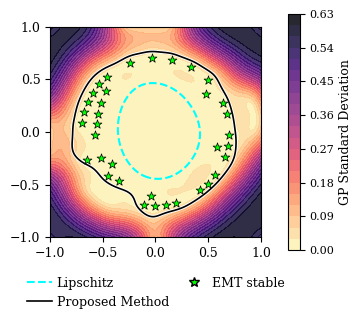

💾 Explored GP dataset saved (426 pts).


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import logging

# 屏蔽字体缓存警告
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# ==========================================
# 1. 严格符合 IEEE 单栏要求的字体与尺寸配置
# ==========================================
plt.rcParams['font.family'] = 'Dejavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'  # 保证数学公式 $x_1, x_2$ 也是 Times 风格

# 将所有文本字体大小统一设为 9 pt
for _k in ['font.size', 'axes.labelsize', 'axes.titlesize',
           'xtick.labelsize', 'ytick.labelsize', 'legend.fontsize']:
    plt.rcParams[_k] = 9

# IEEE 单栏标准宽度约为 3.5 英寸，高度设为 3.2 左右能完美容纳下方的图例
fig = plt.figure(figsize=(3.5, 3.2), layout='constrained')
ax = fig.add_subplot(1, 1, 1)

# ==========================================
# 2. 核心绘图部分 (限制范围到 -1.0 到 1.0)
# ==========================================
# 数据生成
PLOT_LIM = 1.5
PLOT_RES = 200
_axis = np.linspace(-PLOT_LIM, PLOT_LIM, PLOT_RES)
_X1, _X2 = np.meshgrid(_axis, _axis)
_grid = np.stack([_X1.ravel(), _X2.ravel()], axis=1)

mu_fin, sd_fin = gpr_exp.predict(_grid, return_std=True)
STD_final = sd_fin.reshape(PLOT_RES, PLOT_RES)
LCB_final = (mu_fin - 3*sd_fin).reshape(PLOT_RES, PLOT_RES)

_grid_t = torch.tensor(_grid, dtype=torch.float32).to(device)
with torch.no_grad():
    V_nn_grid = model(_grid_t).cpu().numpy().reshape(PLOT_RES, PLOT_RES)

# 绘制热力图
cf = ax.contourf(_X1, _X2, STD_final, levels=20, cmap='magma_r', alpha=0.85)

# 绘制色标 (Colorbar)
# 为了适应 IEEE 单栏，我们将分馏条移至图表上方 (top)，并用 shrink 调整长度使其美观
cb = fig.colorbar(cf, ax=ax, location='right', shrink=0.9, pad=0.02)
cb.set_label('GP Standard Deviation', labelpad=3)
cb.ax.tick_params(labelsize=8) # 刻度稍微小一点，更显精致

# NN inner ROA
ax.contour(_X1, _X2, V_nn_grid - c_level_to_plot, levels=[0],
           colors='cyan', linewidths=1.5, linestyles='--')

# Final refined ROA (白底黑线组合圈)
ax.contour(_X1, _X2, LCB_final - LCB_THRESHOLD, levels=[0], colors='white', linewidths=2.5)
ax.contour(_X1, _X2, LCB_final - LCB_THRESHOLD, levels=[0], colors='black', linewidths=1.2, linestyles='-')

# EMT queries — 适当缩小了 Marker 尺寸以适应 3.5 英寸的小画布
for x_q, lbl, rd_i, sd_q in all_emt_queries:
    if lbl > 0.5:
        ax.scatter(x_q[0], x_q[1], color='lime', marker='*', s=45,
                   edgecolors='black', linewidths=0.5, zorder=6)
    else:
        ax.scatter(x_q[0], x_q[1], color='red', marker='x', s=30,
                   linewidths=1.2, zorder=6)

# 坐标轴限制与标签
ax.set_xlim(-1.0, 1.0)
ax.set_ylim(-1.0, 1.0)
ax.set_xticks([-1.0, -0.5, 0, 0.5, 1.0])
ax.set_yticks([-1.0, -0.5, 0, 0.5, 1.0])
# ax.set_xlabel('$x_1$', labelpad=2)
# ax.set_ylabel('$x_2$', labelpad=2)
ax.set_aspect('equal')
ax.grid(False) # 显式关闭网格线

# ==========================================
# 3. 图例 (Legend) 调整
# ==========================================
# 缩减了内部线条的粗细和长度，防止图例超出页面边界
handles = [
    mlines.Line2D([], [], color='cyan', lw=1.5, ls='--', label='Lipschitz'),
    mlines.Line2D([], [], color='black', lw=1.2, label='Proposed Method'),
    mlines.Line2D([], [], color='lime', marker='*', lw=0, markersize=7, markeredgecolor='k', label='EMT stable'),
]

# 将图例平铺放在下方，ncol=2 自动折行，避免单行太长溢出
ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.15),
          ncol=2, frameon=False, borderpad=0.1, handletextpad=0.4, columnspacing=1.0)

# 保存为高质量矢量图提交给 IEEE
plt.savefig('SMIB_Extended', dpi=300)
plt.show()
print(f"💾 Explored GP dataset saved ({X_exp.shape[0]} pts).")

In [ ]:
# 把经过千辛万苦主动学习攒下来的最终数据集保存到本地
np.savez('GP_Final_Dataset.npz', X_train=X_train, y_train=y_train)
print("✅ GP 最终训练数据已成功保存为 GP_Final_Dataset.npz")

✅ GP 最终训练数据已成功保存为 GP_Final_Dataset.npz


🚀 正在加载已完成的 GP 训练数据，重建模型...
🎲 正在进行 Monte Carlo 面积积分 (200,000 个采样点)...
ROA Area Comparison vs. Physics Limit (V_c):
-> Physical Energy Boundary : 100.00% (Baseline)


NameError: name 'N_energy' is not defined

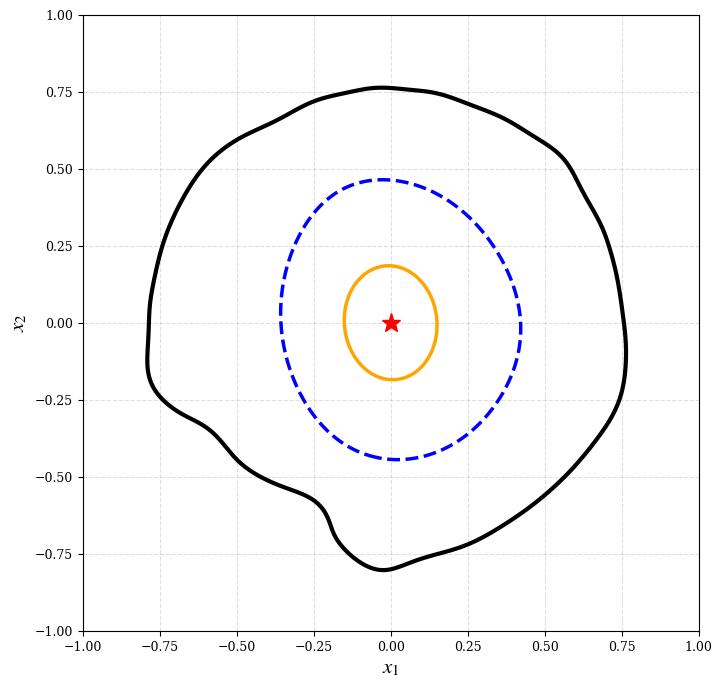

In [ ]:
# ---------- Block 7: Ultimate ROA Comparison (Decoupled & Fast) ----------
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.linalg import solve_continuous_are
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
import logging
import warnings
import os

warnings.filterwarnings('ignore')
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
plt.rcParams.update({'font.family': 'Dejavu Serif', 'font.serif': ['Times New Roman'], 'font.size': 11})

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 1. 统一的系统参数 (严格使用训练时的参数)
# ==========================================
Pm, M, D, K = 2.0, 1.0, 0.1, 2.5
delta_s = np.arcsin(Pm / K)
x1_uep = np.pi - 2 * delta_s

# 画布视野放大，但网格变密，保证曲线平滑
plot_limit = 1
grid_res = 200
axis_range = np.linspace(-plot_limit, plot_limit, grid_res)
X1, X2 = np.meshgrid(axis_range, axis_range)
grid_points = np.stack([X1.ravel(), X2.ravel()], axis=1)
grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)

# ==========================================
# 2. 准备各种方法的评价指标
# ==========================================
# # (A) Energy Function (Vc)
# V_shift = 0.5 * M * X2**2 - K * (np.cos(X1 + delta_s) - np.cos(delta_s)) - Pm * X1
# Vc = 0.5 * M * 0**2 - K * (np.cos(x1_uep + delta_s) - np.cos(delta_s)) - Pm * x1_uep

# (B) LQR-Lyapunov
A_mat = np.array([[0.0, 1.0], [-(K / M) * np.cos(delta_s), -D / M]])
B_mat = np.array([[0.0], [1.0 / M]])
Q_mat = np.diag([0.1, 0.1])
R_mat = np.array([[10]])
P_mat = solve_continuous_are(A_mat, B_mat, Q_mat, R_mat)
P_mat = 0.5 * (P_mat + P_mat.T)

V_lqr = P_mat[0,0]*X1**2 + 2*P_mat[0,1]*X1*X2 + P_mat[1,1]*X2**2
dV_lqr = 2*(P_mat[0,0]*X1 + P_mat[0,1]*X2)*X2 + 2*(P_mat[1,0]*X1 + P_mat[1,1]*X2)*((Pm - K*np.sin(X1+delta_s) - D*X2)/M)

flatV, flatdV = V_lqr.ravel(), dV_lqr.ravel()
mask = flatV > 1e-12
V_sorted = np.sort(flatV[mask])
dV_sorted = flatdV[mask][np.argsort(flatV[mask])]
running_max = np.maximum.accumulate(dV_sorted)
ok = np.where(running_max <= 1e-5)[0]
c_star_lqr = V_sorted[ok[-1]] if len(ok) > 0 else 0.001

# (C) Theoretical Neural Lyapunov
class LyapunovNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, 16), nn.Tanh(), nn.Linear(16, 16), nn.Tanh(), nn.Linear(16, 2))
    def forward(self, x): return torch.sum(self.net(x)**2, dim=1, keepdim=True)

model = LyapunovNetwork().to(device)
model.load_state_dict(torch.load("Lipschitz_VSM_GP.pt", map_location=device))
model.eval()
with torch.no_grad():
    V_nn = model(grid_tensor).cpu().numpy().reshape(grid_res, grid_res)
c_level_nn = 0.9

# (D) GP Expanded ROA (✨ 核心改动：直接加载训练好的数据)
if not os.path.exists('GP_Explored_Dataset.npz'):
    raise FileNotFoundError("❌ 找不到 GP_Final_Dataset.npz！请先在你的 Block 6 代码末尾加上保存数据的代码并运行一次。")

print("🚀 正在加载已完成的 GP 训练数据，重建模型...")
data = np.load('GP_Explored_Dataset.npz')
X_tr, y_tr = data['X_train'], data['y_train']

# 使用与 Block 6 100% 一模一样的参数重建 GP 并进行一次拟合
kernel = C(1.0, (1e-3, 1e3)) * RBF(0.5, (1e-2, 1e2))
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3, alpha=1e-4, random_state=SEED)
gpr.fit(X_tr, y_tr)

# 计算全局网格的 LCB
mu, std = gpr.predict(grid_points, return_std=True)
LCB_grid = (mu - 3 * std).reshape(grid_res, grid_res)

# # ==========================================
# # 3. 蒙特卡洛 (Monte Carlo) 计算精准覆盖率
# # ==========================================
print("🎲 正在进行 Monte Carlo 面积积分 (200,000 个采样点)...")
N_mc = 200000
mc_pts = np.random.uniform(-plot_limit, plot_limit, (N_mc, 2))
mc_tensor = torch.tensor(mc_pts, dtype=torch.float32).to(device)

V_shift_mc = 0.5 * M * mc_pts[:,1]**2 - K * (np.cos(mc_pts[:,0] + delta_s) - np.cos(delta_s)) - Pm * mc_pts[:,0]
# N_energy = np.sum(V_shift_mc <= Vc)

V_lqr_mc = P_mat[0,0]*mc_pts[:,0]**2 + 2*P_mat[0,1]*mc_pts[:,0]*mc_pts[:,1] + P_mat[1,1]*mc_pts[:,1]**2
N_lqr = np.sum(V_lqr_mc <= c_star_lqr)

with torch.no_grad(): V_nn_mc = model(mc_tensor).cpu().numpy().flatten()
N_nn = np.sum((V_nn_mc <= c_level_nn) & (np.linalg.norm(mc_pts, axis=1) <= 0.47))

mu_mc, std_mc = gpr.predict(mc_pts, return_std=True)
N_gp = np.sum((mu_mc - 3 * std_mc) > 0.80)

print("=" * 50)
print("ROA Area Comparison vs. Physics Limit (V_c):")
print(f"-> Physical Energy Boundary : 100.00% (Baseline)")
# print(f"-> 1. LQR-Lyapunov Method   : {N_lqr / N_energy * 100:>6.2f}%")
# # print(f"-> 2. Theoretical Neural ROA: {N_nn / N_energy * 100:>6.2f}%")
# print(f"-> 3. GP Expanded ROA (LCB) : {N_gp / N_energy * 100:>6.2f}%")
print("=" * 50)

# ==========================================
# 4. 强制 Equal Aspect Ratio 绘图
# ==========================================
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal', adjustable='box') # 消除视觉压缩错觉

# ax.contour(X1, X2, V_shift, levels=[Vc], colors='seagreen', linewidths=2.5, linestyles='solid')
ax.contour(X1, X2, V_lqr, levels=[c_star_lqr], colors='orange', linewidths=2.5, linestyles='solid')
ax.contour(X1, X2, V_nn - c_level_nn, levels=[0], colors='blue', linewidths=2.5, linestyles='--')
ax.contour(X1, X2, LCB_grid - 0.80, levels=[0], colors='black', linewidths=3.0, linestyles='solid')

ax.plot(0, 0, 'r*', ms=14, zorder=5)
# ax.plot(x1_uep, 0, 'kX', ms=12, zorder=5)

ax.set_xlim(-plot_limit, plot_limit)
ax.set_ylim(-plot_limit, plot_limit)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.grid(True, ls='--', alpha=0.4)

# h1 = mlines.Line2D([], [], color='seagreen', lw=2.5, label='Physical Bound (Energy $V_c$)')
h2 = mlines.Line2D([], [], color='orange', lw=2.5, label=f'LQR ({N_lqr/N_energy*100:.1f}%)')
h3 = mlines.Line2D([], [], color='blue', lw=2.5, ls='--', label=f'Lipschitz({N_nn/N_energy*100:.1f}%)')
h4 = mlines.Line2D([], [], color='black', lw=3.0, label=f'GP Expanded ({N_gp/N_energy*100:.1f}%)')
ax.legend(handles=[h2, h3, h4], loc='lower center', bbox_to_anchor=(0.5, 1), ncol=3, framealpha=0.9)

# plt.title("Monte Carlo ROA Coverage Comparison")
plt.tight_layout()
plt.show()

🚀 正在加载已完成的 GP 训练数据，重建模型...
🎲 正在进行 Monte Carlo 面积积分 (200,000 个采样点)...
ROA Area Percentage in [-1, 1] Region:
-> 1. LQR-Lyapunov Method   :  2.23%
-> 2. Theoretical Neural ROA: 13.80%
-> 3. GP Expanded ROA (LCB) : 44.63%


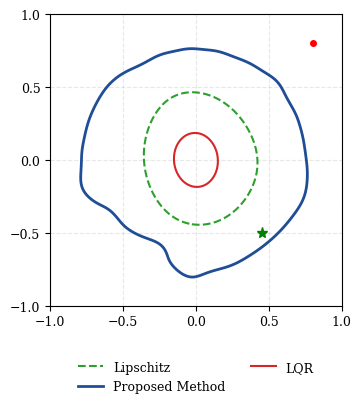

In [ ]:
# ---------- Block 7: Ultimate ROA Comparison (IEEE Single Column) ----------
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.linalg import solve_continuous_are
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
import logging
import warnings
import os

warnings.filterwarnings('ignore')
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# ==========================================
# 1. 严格符合 IEEE 单栏要求的字体与尺寸配置
# ==========================================
plt.rcParams['font.family'] = 'Dejavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'
for _k in ['font.size', 'axes.labelsize', 'axes.titlesize',
           'xtick.labelsize', 'ytick.labelsize', 'legend.fontsize']:
    plt.rcParams[_k] = 9

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. 统一的系统参数 (严格使用训练时的参数)
# ==========================================
Pm, M, D, K = 2.0, 1.0, 0.1, 2.5
delta_s = np.arcsin(Pm / K)
x1_uep = np.pi - 2 * delta_s

plot_limit = 1
grid_res = 200
axis_range = np.linspace(-plot_limit, plot_limit, grid_res)
X1, X2 = np.meshgrid(axis_range, axis_range)
grid_points = np.stack([X1.ravel(), X2.ravel()], axis=1)
grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)

# ==========================================
# 3. 准备各种方法的评价指标
# ==========================================
# (A) LQR-Lyapunov
A_mat = np.array([[0.0, 1.0], [-(K / M) * np.cos(delta_s), -D / M]])
B_mat = np.array([[0.0], [1.0 / M]])
Q_mat = np.diag([0.1, 0.1])
R_mat = np.array([[10]])
P_mat = solve_continuous_are(A_mat, B_mat, Q_mat, R_mat)
P_mat = 0.5 * (P_mat + P_mat.T)

V_lqr = P_mat[0,0]*X1**2 + 2*P_mat[0,1]*X1*X2 + P_mat[1,1]*X2**2
dV_lqr = 2*(P_mat[0,0]*X1 + P_mat[0,1]*X2)*X2 + 2*(P_mat[1,0]*X1 + P_mat[1,1]*X2)*((Pm - K*np.sin(X1+delta_s) - D*X2)/M)

flatV, flatdV = V_lqr.ravel(), dV_lqr.ravel()
mask = flatV > 1e-12
V_sorted = np.sort(flatV[mask])
dV_sorted = flatdV[mask][np.argsort(flatV[mask])]
running_max = np.maximum.accumulate(dV_sorted)
ok = np.where(running_max <= 1e-5)[0]
c_star_lqr = V_sorted[ok[-1]] if len(ok) > 0 else 0.001

# (B) Theoretical Neural Lyapunov
class LyapunovNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, 16), nn.Tanh(), nn.Linear(16, 16), nn.Tanh(), nn.Linear(16, 2))
    def forward(self, x): return torch.sum(self.net(x)**2, dim=1, keepdim=True)

model = LyapunovNetwork().to(device)
model.load_state_dict(torch.load("Lipschitz_VSM_GP.pt", map_location=device))
model.eval()
with torch.no_grad():
    V_nn = model(grid_tensor).cpu().numpy().reshape(grid_res, grid_res)
c_level_nn = 0.9

# (C) GP Expanded ROA
if not os.path.exists('GP_Explored_Dataset.npz'):
    raise FileNotFoundError("❌ 找不到 GP_Explored_Dataset.npz！")

print("🚀 正在加载已完成的 GP 训练数据，重建模型...")
data = np.load('GP_Explored_Dataset.npz')
X_tr, y_tr = data['X_train'], data['y_train']

kernel = C(1.0, (1e-3, 1e3)) * RBF(0.5, (1e-2, 1e2))
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3, alpha=1e-4, random_state=SEED)
gpr.fit(X_tr, y_tr)

mu, std = gpr.predict(grid_points, return_std=True)
LCB_grid = (mu - 3 * std).reshape(grid_res, grid_res)

# ==========================================
# 4. 蒙特卡洛 (Monte Carlo) 计算精准面积
# ==========================================
print("🎲 正在进行 Monte Carlo 面积积分 (200,000 个采样点)...")
N_mc = 200000
mc_pts = np.random.uniform(-plot_limit, plot_limit, (N_mc, 2))
mc_tensor = torch.tensor(mc_pts, dtype=torch.float32).to(device)

# 计算 LQR 面积点数
V_lqr_mc = P_mat[0,0]*mc_pts[:,0]**2 + 2*P_mat[0,1]*mc_pts[:,0]*mc_pts[:,1] + P_mat[1,1]*mc_pts[:,1]**2
N_lqr = np.sum(V_lqr_mc <= c_star_lqr)

# 计算 Lipschitz NN 面积点数
with torch.no_grad():
    V_nn_mc = model(mc_tensor).cpu().numpy().flatten()
N_nn = np.sum((V_nn_mc <= c_level_nn) & (np.linalg.norm(mc_pts, axis=1) <= 0.47))

# 计算 GP 面积点数
mu_mc, std_mc = gpr.predict(mc_pts, return_std=True)
N_gp = np.sum((mu_mc - 3 * std_mc) > 0.80)

# ==========================================
# 4. 蒙特卡洛 (Monte Carlo) 计算面积百分比
# ==========================================
# ... (保留前面撒点和计算 N_lqr, N_nn, N_gp 的代码) ...

# 计算占整个 [-1, 1] 区域的百分比
pct_lqr = (N_lqr / N_mc) * 100
pct_nn = (N_nn / N_mc) * 100
pct_gp = (N_gp / N_mc) * 100

print("=" * 50)
print("ROA Area Percentage in [-1, 1] Region:")
print(f"-> 1. LQR-Lyapunov Method   : {pct_lqr:>5.2f}%")
print(f"-> 2. Theoretical Neural ROA: {pct_nn:>5.2f}%")
print(f"-> 3. GP Expanded ROA (LCB) : {pct_gp:>5.2f}%")
print("=" * 50)

# ==========================================
# 5. 强制 Equal Aspect Ratio 绘图 (单栏尺寸适配)
# ==========================================
# 设定为 3.5 英寸宽，高度稍微加大以容纳底部的图例
fig, ax = plt.subplots(figsize=(3.5, 4.2), layout='constrained')
ax.set_aspect('equal', adjustable='box')

# 绘制半透明填充增强对比度

# 绘制边界线 (根据画布缩小了线宽)
ax.contour(X1, X2, V_lqr, levels=[c_star_lqr], colors='#d62728', linewidths=1.5, linestyles='solid')
ax.contour(X1, X2, V_nn - c_level_nn, levels=[0], colors='#2ca02c', linewidths=1.5, linestyles='--')
ax.contour(X1, X2, LCB_grid - 0.80, levels=[0], colors='#1f4e96', linewidths=2.0, linestyles='solid')

# 标记原点
ax.plot(0.45, -0.5, 'g*', ms=8, zorder=5)
ax.plot(0.8, 0.8, 'r.', ms=8, zorder=5)


ax.set_xlim(-plot_limit, plot_limit)
ax.set_ylim(-plot_limit, plot_limit)
ax.set_xticks([-1.0, -0.5, 0, 0.5, 1.0])
ax.set_yticks([-1.0, -0.5, 0, 0.5, 1.0])
# ax.set_xlabel('$x_1$', labelpad=2)
# ax.set_ylabel('$x_2$', labelpad=2)
ax.grid(True, ls='--', alpha=0.3)

# 图例设定：使用垂直排列 (ncol=1) 防止在 3.5 英寸宽度下文字互相重叠
# 图例设定：使用垂直排列 (ncol=1) 防止在 3.5 英寸宽度下文字互相重叠
h2 = mlines.Line2D([], [], color='#d62728', lw=1.5, label=f'LQR')
h4 = mlines.Line2D([], [], color='#2ca02c', lw=1.5, ls='--', label=f'Lipschitz')
h3 = mlines.Line2D([], [], color='#1f4e96', lw=2.0, label=f'Proposed Method')

ax.legend(handles=[h4, h3, h2], loc='upper center', bbox_to_anchor=(0.5, -0.15),
          ncol=2, frameon=False)
# plt.savefig('SMIB_comp', dpi=300)
plt.show()